# 🎵 Model Inference Demo

Interactive demonstration of trained RL models for music recommendation.

---

In [1]:
# Setup and Imports
import sys
import os
from pathlib import Path

# Add project root to path and change working directory
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)  # Change to project root for correct data paths

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Imports successful!")
print(f"📁 Project root: {project_root}")
print(f"📁 Working directory: {Path.cwd()}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"💻 CUDA available: {torch.cuda.is_available()}")

✅ Imports successful!
📁 Project root: c:\Users\amine\Documents\ACADEMIC\MUSIQ
📁 Working directory: c:\Users\amine\Documents\ACADEMIC\MUSIQ
🔥 PyTorch version: 2.9.1+cpu
💻 CUDA available: False


## 1. Load Environment and Model

---

In [2]:
from src.config.base_config import Config, SACConfig
from src.envs.music_env import MusicEnv
from src.agents.sac_agent import SACAgent
from src.agents.cql_agent import CQLAgent

# Configuration - Change these to switch models
CHECKPOINT_PATH = "checkpoints/sac_experiment/best_model.agent.pt"  # Change to your model
ALGORITHM = "sac"  # 'sac' or 'cql'

# Load config
config = Config.from_yaml(f"config/{ALGORITHM}_config.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"📊 Configuration loaded")
print(f"   • Algorithm: {ALGORITHM.upper()}")
print(f"   • Mode: {config.env.mode}")
print(f"   • Device: {device}")

📊 Configuration loaded
   • Algorithm: SAC
   • Mode: continuous
   • Device: cpu


In [3]:
# Create environment
env = MusicEnv(
    data_path=config.env.data_path,
    mode=config.env.mode,
    max_session_length=config.env.max_session_length,
    num_recent_tracks=config.env.num_recent_tracks,
    user_embed_dim=config.env.user_embed_dim,
    song_embed_dim=config.env.song_embed_dim
)

# Get dimensions
if len(env.observation_space.shape) > 1:
    state_dim = env.observation_space.shape[1]
else:
    state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0] if hasattr(env.action_space, 'shape') else env.action_space.n

print(f"\n🌍 Environment created")
print(f"   • State dim: {state_dim}")
print(f"   • Action dim: {action_dim}")
print(f"   • Number of songs: {len(env.songs_df):,}")
print(f"   • Number of users: {len(env.user_ids):,}")

15:22:02 | INFO     | Initializing MusicEnv in continuous mode
15:22:02 | INFO     | Data path: data\raw
15:22:02 | INFO     | Loading datasets...
15:22:02 | INFO     | Loaded 20778 songs
15:22:02 | INFO     | Extracted song embeddings: (20778, 8)
15:22:02 | WARNING  | Interactions file not found, will use synthetic user behavior
15:22:02 | INFO     | Extracted 6 song features
15:22:02 | INFO     | Normalized song features
15:22:02 | INFO     | Generating user embeddings from listening history...
15:22:02 | WARNING  | Generated 1000 synthetic users
15:22:02 | INFO     | Normalized embeddings
15:22:02 | INFO     | Continuous action space: 8-dim
15:22:02 | INFO     | Observation space: 76-dim
15:22:02 | SUCCESS  | MusicEnv initialized successfully

🌍 Environment created
   • State dim: 76
   • Action dim: 8
   • Number of songs: 20,778
   • Number of users: 1,000


In [4]:
# Create and load agent
agent_config = config.get_agent_config()

if ALGORITHM == "cql":
    agent = CQLAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        learning_rate=agent_config.learning_rate,
        gamma=agent_config.gamma,
        tau=agent_config.tau,
        alpha=agent_config.alpha,
        automatic_entropy_tuning=agent_config.automatic_entropy_tuning,
        batch_size=agent_config.batch_size,
        buffer_size=agent_config.buffer_size,
        network_config=agent_config.network_config.model_dump(),
        device=device
    )
else:
    agent = SACAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        learning_rate=agent_config.learning_rate,
        gamma=agent_config.gamma,
        tau=agent_config.tau,
        alpha=agent_config.alpha,
        automatic_entropy_tuning=agent_config.automatic_entropy_tuning,
        batch_size=agent_config.batch_size,
        buffer_size=agent_config.buffer_size,
        network_config=agent_config.network_config.model_dump(),
        device=device
    )

# Load checkpoint
agent.load(CHECKPOINT_PATH)
agent.eval_mode()

print(f"\n🤖 Agent loaded from: {CHECKPOINT_PATH}")
print(f"   • Training steps: {agent.training_step:,}")

15:22:09 | INFO     | Initialized SACAgent | State dim: 76 | Action dim: 8 | Device: cpu
15:22:11 | SUCCESS  | SAC Agent initialized | Auto entropy: True | Buffer size: 1,000,000
15:22:11 | INFO     | Loaded SAC checkpoint from checkpoints/sac_experiment/best_model.agent.pt

🤖 Agent loaded from: checkpoints/sac_experiment/best_model.agent.pt
   • Training steps: 44,140


## 2. Song Database Preview

---

In [5]:
# Display song database
songs_df = env.songs_df.copy()

display_cols = ['track_id', 'track_name', 'artist_name', 'danceability', 'energy', 'valence', 'tempo']
available_cols = [c for c in display_cols if c in songs_df.columns]

print("🎶 Song Database Sample")
print("=" * 60)
display(songs_df[available_cols].head(10).style.format(precision=2).background_gradient(cmap='Blues', subset=[c for c in available_cols if c not in ['track_id', 'track_name', 'artist_name']]))

🎶 Song Database Sample


,track_id,danceability,energy,valence,tempo
0,t_3c2c29b5-c738-42c0-83e1-ee0e88ac834d,0.40,0.34,0.38,133.52
1,t_f48322ca-044e-4069-a797-4fedbbbbb522,0.92,0.73,0.75,103.30
2,t_5487f622-5641-43da-b263-d8954845d163,0.28,0.57,0.58,169.90
3,t_7345e2b8-5f72-440f-a0fc-81bf7e8996f2,0.70,0.58,0.86,134.38
4,t_faa63385-9547-4b18-b942-529285cc2ab6,0.53,0.89,0.72,122.49
5,t_949ec21d-0f16-4e81-b0ff-aa362bfe21df,0.76,0.66,0.93,118.39
6,t_3599274a-c2c5-4fa2-bf0d-d4dae2a4cdde,0.68,0.39,0.76,103.56
7,t_3b45b0b3-228b-45e9-baab-2782e98d3e97,0.76,0.88,0.95,102.76
8,t_a52c7c4e-3547-43f6-b5e5-596cdd131be5,0.67,0.59,0.55,102.72
9,t_95610045-549c-46a7-bda3-d18bbac22620,0.41,0.27,0.46,83.22


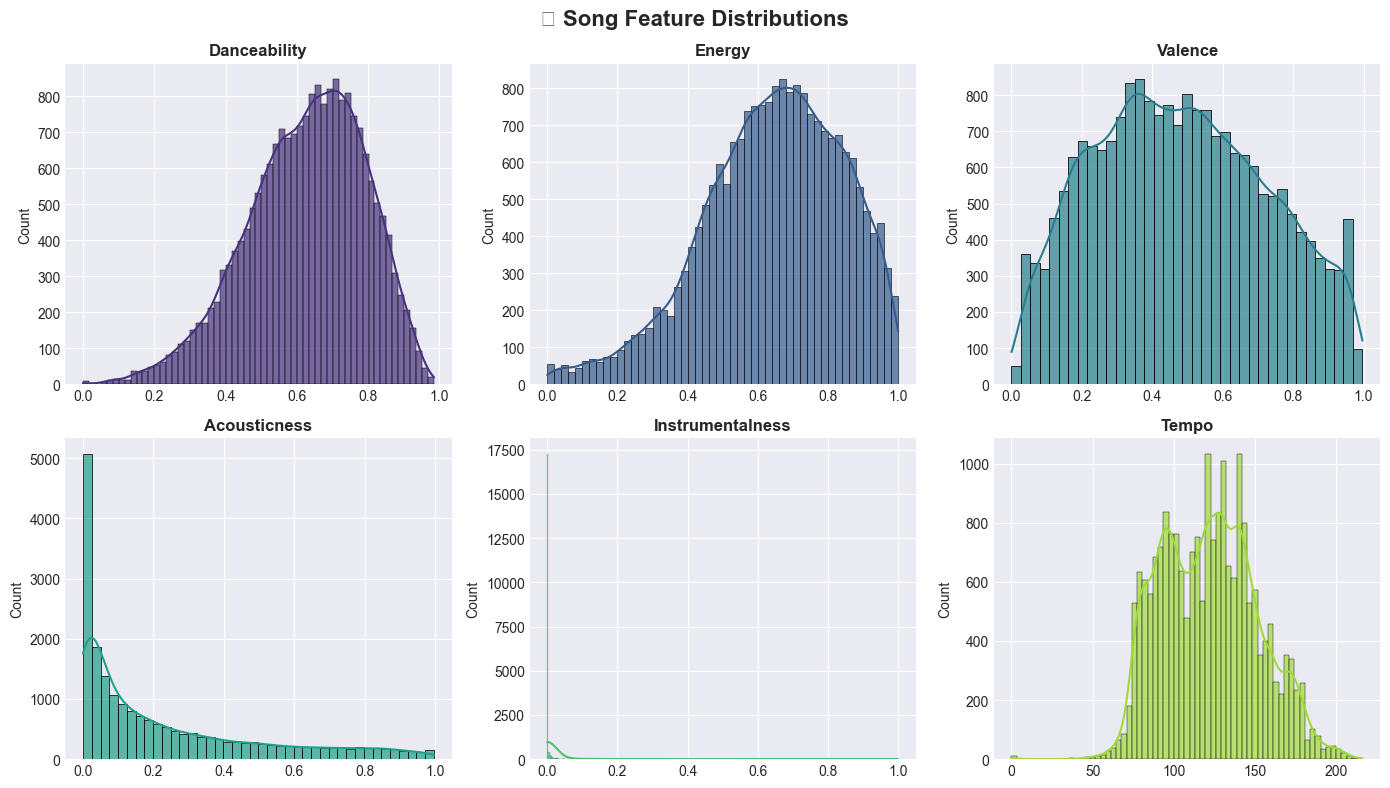

In [6]:
# Song feature distributions
feature_cols = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'tempo']
available_features = [c for c in feature_cols if c in songs_df.columns]

if available_features:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle('🎵 Song Feature Distributions', fontsize=16, fontweight='bold')
    
    colors = sns.color_palette('viridis', len(available_features))
    
    for idx, (col, ax) in enumerate(zip(available_features, axes.flat)):
        sns.histplot(songs_df[col], ax=ax, color=colors[idx], kde=True, alpha=0.7)
        ax.set_title(col.title(), fontweight='bold')
        ax.set_xlabel('')
    
    plt.tight_layout()
    plt.show()

## 3. Interactive Recommendation Session

---

In [7]:
def get_song_info(song_idx, songs_df):
    """Get formatted song information"""
    song = songs_df.iloc[song_idx]
    info = {
        'Track': song.get('track_name', f'Song {song_idx}'),
        'Artist': song.get('artist_name', 'Unknown'),
        'Danceability': song.get('danceability', 0),
        'Energy': song.get('energy', 0),
        'Valence': song.get('valence', 0),
    }
    return info

def display_recommendation(song_info, step):
    """Display recommendation in a nice format"""
    html = f"""
    <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                padding: 20px; border-radius: 15px; margin: 10px 0; color: white;">
        <h3 style="margin: 0 0 10px 0;">🎵 Recommendation #{step}</h3>
        <h2 style="margin: 0 0 5px 0;">{song_info['Track']}</h2>
        <p style="margin: 0 0 15px 0; opacity: 0.9;">by {song_info['Artist']}</p>
        <div style="display: flex; gap: 20px;">
            <span>💃 Dance: {song_info['Danceability']:.2f}</span>
            <span>⚡ Energy: {song_info['Energy']:.2f}</span>
            <span>😊 Valence: {song_info['Valence']:.2f}</span>
        </div>
    </div>
    """
    display(HTML(html))

In [8]:
# Run a recommendation session
NUM_RECOMMENDATIONS = 10

state, info = env.reset()
session_data = []

print(f"👤 User: {info['user_id']}")
print("=" * 60)

for step in range(1, NUM_RECOMMENDATIONS + 1):
    # Get action from agent
    action = agent.act(state, training=False)
    
    # Execute action
    next_state, reward, terminated, truncated, step_info = env.step(action)
    
    # Get song info
    song_idx = step_info['song_idx']
    song_info = get_song_info(song_idx, songs_df)
    
    # Store session data
    session_data.append({
        'Step': step,
        'Song': song_info['Track'],
        'Artist': song_info['Artist'],
        'Reaction': ['Skip', 'Partial', 'Full'][step_info['user_reaction']],
        'Reward': reward
    })
    
    # Display recommendation
    display_recommendation(song_info, step)
    
    reaction_emoji = ['⏭️ Skip', '⏸️ Partial', '✅ Full'][step_info['user_reaction']]
    print(f"   Reaction: {reaction_emoji} | Reward: {reward:+.2f}")
    
    state = next_state
    
    if terminated or truncated:
        print(f"\n🔚 Session ended at step {step}")
        break

👤 User: user_365


   Reaction: ⏸️ Partial | Reward: +0.72


   Reaction: ⏭️ Skip | Reward: -0.48


   Reaction: ⏸️ Partial | Reward: +0.93


   Reaction: ⏸️ Partial | Reward: +0.64


...

   Reaction: ⏸️ Partial | Reward: +0.64


   Reaction: ⏸️ Partial | Reward: +0.67


   Reaction: ✅ Full | Reward: +1.19


   Reaction: ✅ Full | Reward: +1.18


   Reaction: ✅ Full | Reward: +1.07


In [9]:
# Session summary
session_df = pd.DataFrame(session_data)

print("\n📊 Session Summary")
print("=" * 60)
display(session_df.style.format({'Reward': '{:+.2f}'}).background_gradient(subset=['Reward'], cmap='RdYlGn'))

# Calculate metrics
total_reward = session_df['Reward'].sum()
skip_rate = (session_df['Reaction'] == 'Skip').mean()
full_rate = (session_df['Reaction'] == 'Full').mean()

print(f"\n🎯 Session Metrics:")
print(f"   • Total Reward: {total_reward:+.2f}")
print(f"   • Skip Rate: {skip_rate:.1%}")
print(f"   • Full Listen Rate: {full_rate:.1%}")


📊 Session Summary


,Step,Song,Artist,Reaction,Reward
0,1,Song 9040,Unknown,Partial,+0.72
1,2,Song 9040,Unknown,Skip,-0.48
2,3,Song 5781,Unknown,Partial,+0.93
3,4,Song 17141,Unknown,Partial,+0.64
4,5,Song 11074,Unknown,Partial,+0.65
5,6,Song 15723,Unknown,Partial,+0.64
6,7,Song 11995,Unknown,Partial,+0.67
7,8,Song 11275,Unknown,Full,+1.19
8,9,Song 7718,Unknown,Full,+1.18
9,10,Song 9040,Unknown,Full,+1.07



🎯 Session Metrics:
   • Total Reward: +7.20
   • Skip Rate: 10.0%
   • Full Listen Rate: 30.0%


## 4. Visualize Recommendation Patterns

---

In [10]:
# Run multiple sessions for pattern analysis
NUM_SESSIONS = 20
all_sessions = []

for session in range(NUM_SESSIONS):
    state, info = env.reset()
    session_rewards = []
    session_reactions = []
    
    for step in range(50):  # Max steps
        action = agent.act(state, training=False)
        next_state, reward, terminated, truncated, step_info = env.step(action)
        
        session_rewards.append(reward)
        session_reactions.append(step_info['user_reaction'])
        
        state = next_state
        if terminated or truncated:
            break
    
    all_sessions.append({
        'session': session,
        'total_reward': sum(session_rewards),
        'length': len(session_rewards),
        'skip_rate': session_reactions.count(0) / len(session_reactions),
        'full_rate': session_reactions.count(2) / len(session_reactions)
    })

sessions_df = pd.DataFrame(all_sessions)
print(f"✅ Ran {NUM_SESSIONS} sessions for analysis")

15:24:17 | INFO     | Episode ended (truncated) | User: user_460 | Length: 20 | Total reward: 12.26 | Avg reward: 0.613 | Skip rate: 25.00% | Completion rate: 35.00%
15:24:17 | INFO     | Episode ended (natural) | User: user_362 | Length: 2 | Total reward: 2.43 | Avg reward: 1.215 | Skip rate: 0.00% | Completion rate: 100.00%
15:24:17 | INFO     | Episode ended (truncated) | User: user_21 | Length: 20 | Total reward: 15.71 | Avg reward: 0.785 | Skip rate: 20.00% | Completion rate: 65.00%
15:24:17 | INFO     | Episode ended (natural) | User: user_723 | Length: 12 | Total reward: 7.46 | Avg reward: 0.622 | Skip rate: 16.67% | Completion rate: 25.00%
15:24:17 | INFO     | Episode ended (natural) | User: user_514 | Length: 6 | Total reward: 1.84 | Avg reward: 0.307 | Skip rate: 50.00% | Completion rate: 16.67%
15:24:17 | INFO     | Episode ended (truncated) | User: user_716 | Length: 20 | Total reward: 17.78 | Avg reward: 0.889 | Skip rate: 10.00% | Completion rate: 60.00%
15:24:17 | INFO 

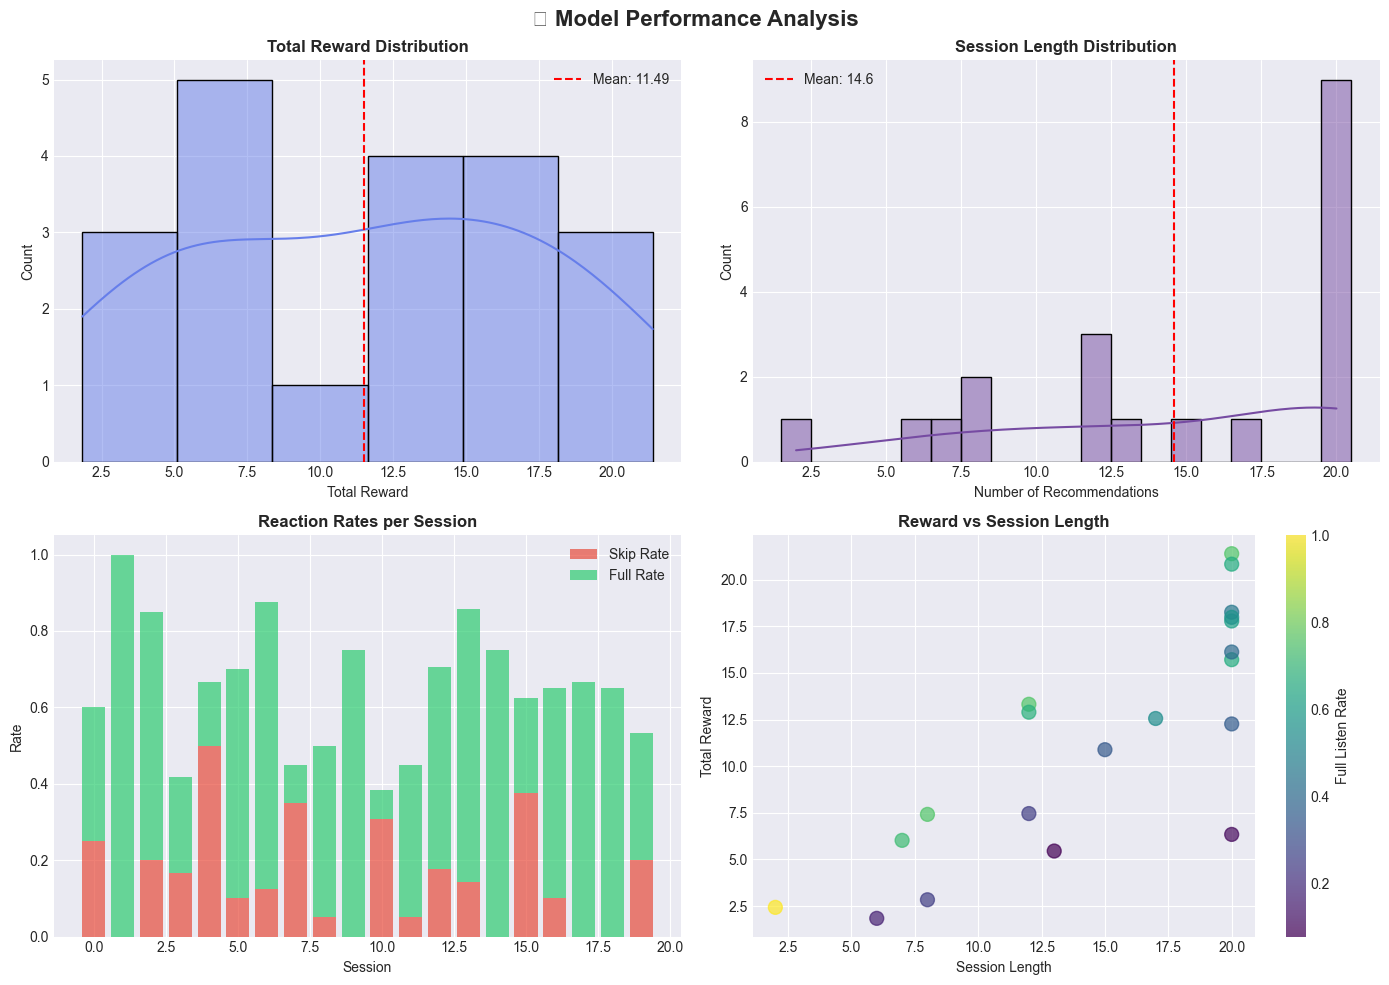

In [11]:
# Visualize session performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Model Performance Analysis', fontsize=16, fontweight='bold')

# Total rewards distribution
ax1 = axes[0, 0]
sns.histplot(sessions_df['total_reward'], ax=ax1, kde=True, color='#667eea')
ax1.axvline(sessions_df['total_reward'].mean(), color='red', linestyle='--', label=f'Mean: {sessions_df["total_reward"].mean():.2f}')
ax1.set_title('Total Reward Distribution', fontweight='bold')
ax1.set_xlabel('Total Reward')
ax1.legend()

# Session lengths
ax2 = axes[0, 1]
sns.histplot(sessions_df['length'], ax=ax2, kde=True, color='#764ba2', discrete=True)
ax2.axvline(sessions_df['length'].mean(), color='red', linestyle='--', label=f'Mean: {sessions_df["length"].mean():.1f}')
ax2.set_title('Session Length Distribution', fontweight='bold')
ax2.set_xlabel('Number of Recommendations')
ax2.legend()

# Skip rate vs Full rate
ax3 = axes[1, 0]
x = range(len(sessions_df))
ax3.bar(x, sessions_df['skip_rate'], alpha=0.7, label='Skip Rate', color='#e74c3c')
ax3.bar(x, sessions_df['full_rate'], alpha=0.7, bottom=sessions_df['skip_rate'], label='Full Rate', color='#2ecc71')
ax3.set_title('Reaction Rates per Session', fontweight='bold')
ax3.set_xlabel('Session')
ax3.set_ylabel('Rate')
ax3.legend()

# Reward vs Length scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(sessions_df['length'], sessions_df['total_reward'], 
                       c=sessions_df['full_rate'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, ax=ax4, label='Full Listen Rate')
ax4.set_title('Reward vs Session Length', fontweight='bold')
ax4.set_xlabel('Session Length')
ax4.set_ylabel('Total Reward')

plt.tight_layout()
plt.savefig('plots/inference_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Summary statistics
print("\n" + "=" * 60)
print("📈 INFERENCE SUMMARY")
print("=" * 60)
print(f"\n🎯 Performance Metrics (across {NUM_SESSIONS} sessions):")
print(f"   • Mean Total Reward: {sessions_df['total_reward'].mean():.2f} ± {sessions_df['total_reward'].std():.2f}")
print(f"   • Mean Session Length: {sessions_df['length'].mean():.1f} ± {sessions_df['length'].std():.1f}")
print(f"   • Mean Skip Rate: {sessions_df['skip_rate'].mean():.1%}")
print(f"   • Mean Full Listen Rate: {sessions_df['full_rate'].mean():.1%}")
print(f"\n✅ Model: {ALGORITHM.upper()}")
print(f"✅ Checkpoint: {CHECKPOINT_PATH}")


📈 INFERENCE SUMMARY

🎯 Performance Metrics (across 20 sessions):
   • Mean Total Reward: 11.49 ± 6.22
   • Mean Session Length: 14.6 ± 5.9
   • Mean Skip Rate: 15.5%
   • Mean Full Listen Rate: 49.9%

✅ Model: SAC
✅ Checkpoint: checkpoints/sac_experiment/best_model.agent.pt
